# Housing Price Prediction

Import relevant packages

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torchvision.transforms import Normalize

sns.set_theme(style="whitegrid", palette="deep", font_scale=1)

kwfig = {
    'format':'pdf',
    'bbox_inches':'tight', 
    'pad_inches':0.0, 
    'transparent':True
}

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

torch.set_default_dtype(torch.float32)

torch.set_printoptions(precision=6, sci_mode=False, linewidth=80)

Import dataset from file and inspect

In [96]:
df = pd.read_csv('data/kc_house_data.csv')

df = df.drop(columns=["id", "date", "lat", "long", "zipcode", "yr_renovated", "sqft_above", "waterfront"])

df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,sqft_basement,yr_built,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,3,7,0,1955,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,3,7,400,1951,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,3,6,0,1933,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,5,7,910,1965,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,3,8,0,1987,1800,7503


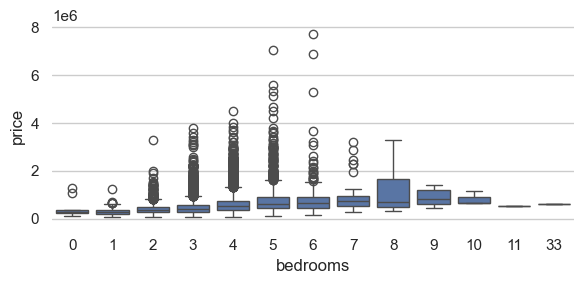

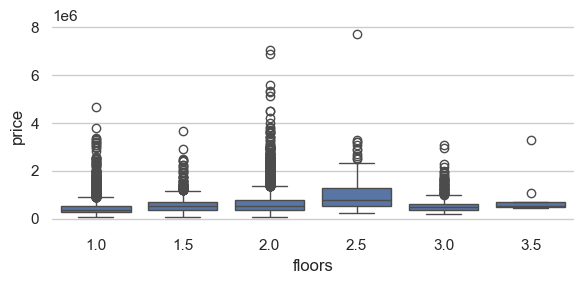

In [40]:
for feature in ["bedrooms", "floors"]:
    fig, ax = plt.subplots(1, 1, figsize=(6,3), tight_layout=True)
    sns.boxplot(x=df[feature], y=df['price'], ax=ax)
    sns.despine(left=True, bottom=True, fig=fig)
    fig.savefig(f'tmp/{feature:s}.{kwfig['format']:s}', **kwfig)

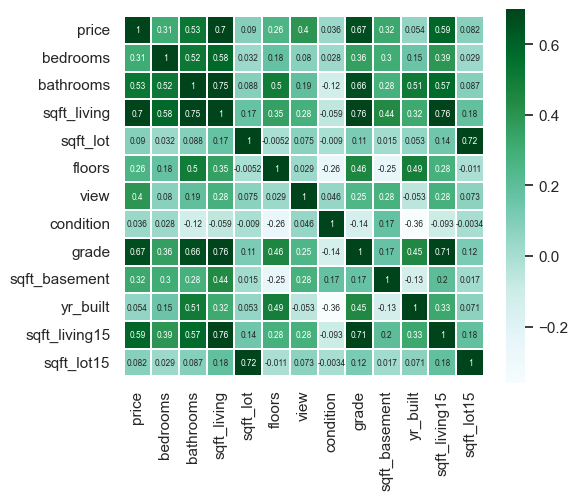

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(6,6), tight_layout=True)

sns.heatmap(
    df.corr(), 
    linewidth=0.25, 
    vmax=0.7, 
    square=True, 
    cmap='BuGn',
    linecolor='w',
    annot=True,
    annot_kws={'size':6},
    cbar_kws={'shrink':0.7},
    ax=ax
)

fig.savefig(f'tmp/heat.{kwfig['format']}', **kwfig)

Preprocess the dataset

In [160]:
features = [
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'view',
    'condition',
    'grade',
    'sqft_basement',
    'yr_built',
    'sqft_living15',
    'sqft_lot15'
]

X = torch.tensor(df[features].to_numpy(), dtype=torch.float32)
Xmean, Xstd = X.mean(), X.std()
X = (X - Xmean) / Xstd
y = torch.tensor(df['price'].to_numpy().reshape(-1,1), dtype=torch.float32)
ymean, ystd = y.mean(), y.std()
y = (y - ymean) / ystd

dataset = torch.utils.data.TensorDataset(X, y)

dataLoader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64, 
    shuffle=True
)

In [181]:
def move(f):
    def moved(model, *args, **kwargs):
        # Get device
        device = next(model.parameters()).get_device()

        # run at cpu and move back
        model = model.to("cpu")
        res = f(model, *args, **kwargs)
        model = model.to(device)

        return res
    return moved

class FCN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self._sequential = torch.nn.Sequential(
            nn.Linear(12, 12),
            nn.ReLU(),
            nn.Linear(12, 12),
            nn.ReLU(),
            nn.Linear(12, 1)
        )
    
    def forward(self, X):
        return self._sequential(X)

def train(model, dataLoader, criterion, optimizer, epochs=1):
    def closure():
        optimizer.zero_grad()
        p = model(X)
        l = criterion(p, y)
        l.backward()
        return l    
    
    # Get device
    device = next(model.parameters()).get_device()

    # training loop
    model.train()
    hist = []
    for epoch in range(epochs):
        loss = 0.0
        for X, y in dataLoader:
            X, y = X.to(device), y.to(device)
            
            # backpropagation
            optimizer.step(closure)
            
            # accumulate loss
            with torch.no_grad():
                loss += criterion(model(X), y).item()
        loss /= len(dataLoader)
        print(f'At epoch: {epoch}, Avg. Loss: {loss}')
        hist.append(loss)
    return hist
        
@move
def score(model, dataLoader):
    # Mean targets
    ybar = torch.zeros_like(dataLoader.dataset[0][1])
    for _, y in dataLoader:
        ybar += y.sum(axis=0)
    ybar /= len(dataLoader.dataset)

    # Coefficient of determination
    model.eval()
    varp, vary = 0.0, 0.0
    with torch.no_grad():
        for X, y in dataLoader:            
            p = model(X)
            varp += torch.sum((p -    y)**2)
            vary += torch.sum((y - ybar)**2)
    return 1.0 - varp / vary
    
model = FCN().to(device)

In [166]:
# Select loss function
criterion = nn.MSELoss(reduction='mean')

# Select optimizer
#optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train model
hist = train(model, dataLoader, criterion, optimizer, epochs=20)

# Save model
torch.save(model.state_dict(), 'tmp/housingPrice.pth')

At epoch: 0, Avg. Loss: 0.4097146484890633
At epoch: 1, Avg. Loss: 0.4055170004625292
At epoch: 2, Avg. Loss: 0.4066286165068841
At epoch: 3, Avg. Loss: 0.40619115482949647
At epoch: 4, Avg. Loss: 0.40388615305959824
At epoch: 5, Avg. Loss: 0.40593061503573985
At epoch: 6, Avg. Loss: 0.40520840627554605
At epoch: 7, Avg. Loss: 0.4034694738730171
At epoch: 8, Avg. Loss: 0.4040688886004087
At epoch: 9, Avg. Loss: 0.40164776349208764
At epoch: 10, Avg. Loss: 0.4028880380579
At epoch: 11, Avg. Loss: 0.4015886261618349
At epoch: 12, Avg. Loss: 0.40094096614764285
At epoch: 13, Avg. Loss: 0.4001598067184877
At epoch: 14, Avg. Loss: 0.39838127772042736
At epoch: 15, Avg. Loss: 0.39927495090213755
At epoch: 16, Avg. Loss: 0.40014247671210557
At epoch: 17, Avg. Loss: 0.4014262611696706
At epoch: 18, Avg. Loss: 0.40079417538184386
At epoch: 19, Avg. Loss: 0.40273278316802524


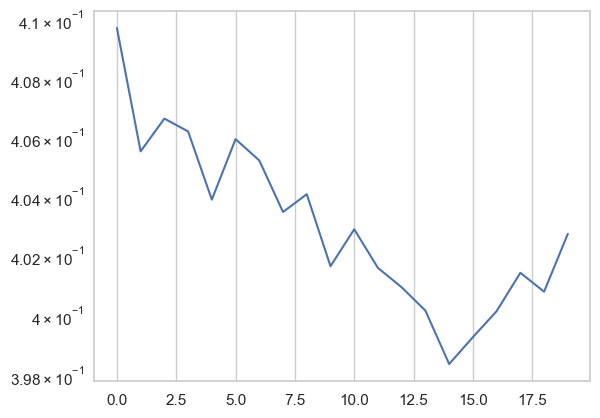

tensor(0.604461)


In [185]:
model.load_state_dict(torch.load('tmp/housingPrice.pth', weights_only=True))

plt.semilogy(hist)
plt.show()

print(score(model, dataLoader))

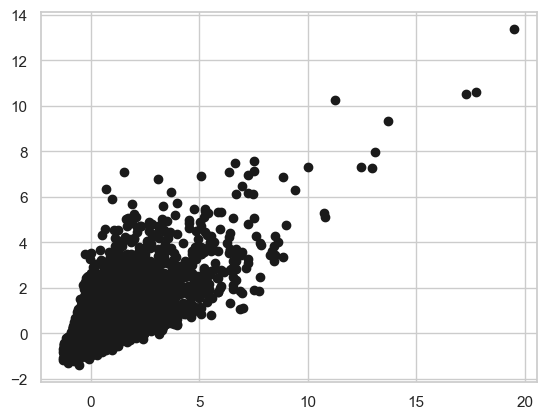

In [183]:
model.load_state_dict(torch.load('tmp/housingPrice.pth', weights_only=True))

model.eval()
with torch.no_grad():
    for X, y in dataLoader:
        X, y = X.to(device), y.to(device)
        
        p = model(X)
        plt.scatter(y.cpu(), p.cpu(), c='k')
plt.show()
    